In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

In [2]:
!pip install seaborn scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 59.1 MB/s  0:00:00 63.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [seaborn]━━━ 1/2 [seaborn]


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

In [5]:
df = pd.read_csv("chickwts.csv")

feed_means = df.groupby("feed")["weight"].mean().sort_values()
feed_means

feed
horsebean    160.200000
linseed      218.750000
soybean      246.428571
meatmeal     276.909091
casein       323.583333
sunflower    328.916667
Name: weight, dtype: float64

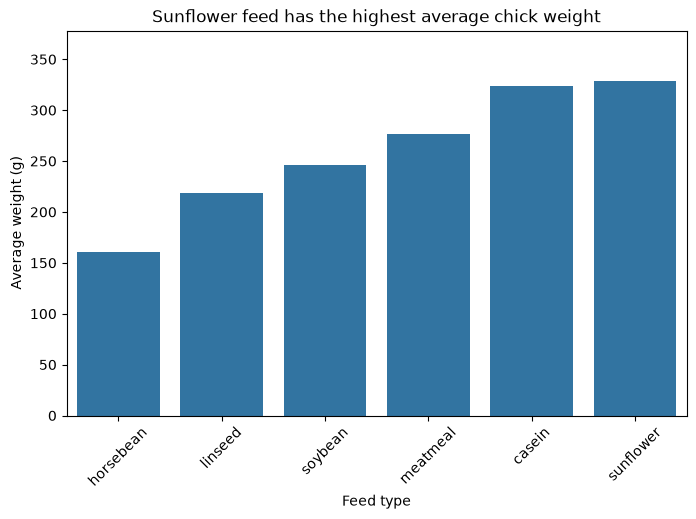

In [6]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x=feed_means.index,
    y=feed_means.values
)

plt.title("Sunflower feed has the highest average chick weight")
plt.xlabel("Feed type")
plt.ylabel("Average weight (g)")
plt.xticks(rotation=45)
plt.ylim(0, feed_means.max() * 1.15)

plt.show()

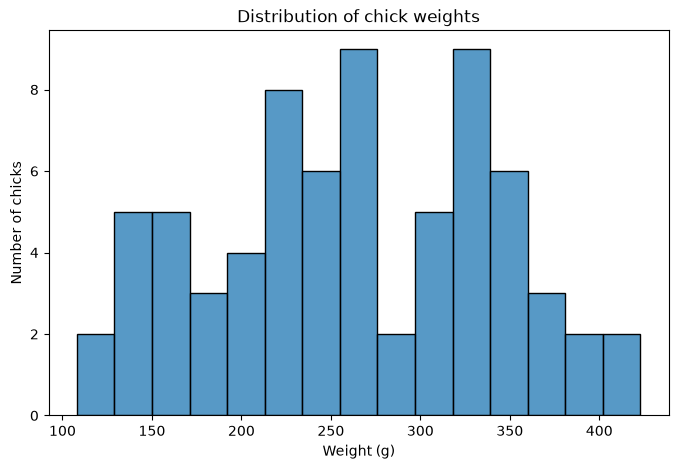

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="weight", bins=15)

plt.title("Distribution of chick weights")
plt.xlabel("Weight (g)")
plt.ylabel("Number of chicks")

plt.show()

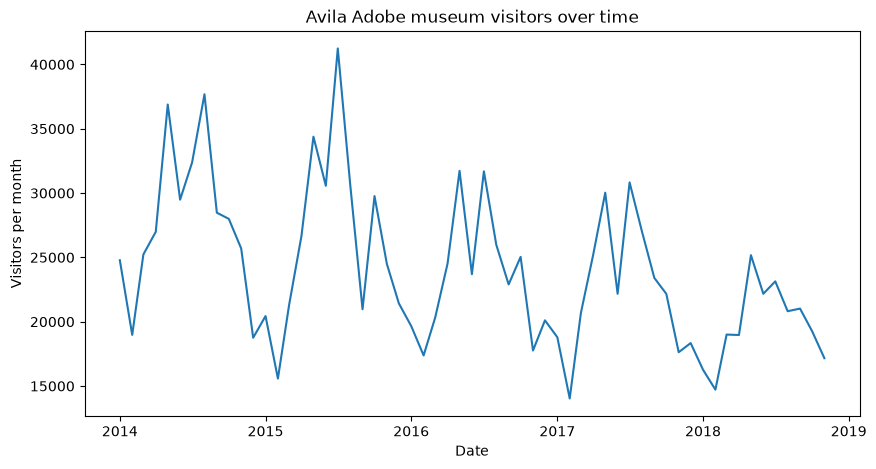

In [8]:
museum = pd.read_csv("museum_visitors.csv")
museum["Date"] = pd.to_datetime(museum["Date"])

plt.figure(figsize=(10, 5))
sns.lineplot(data=museum, x="Date", y="Avila Adobe")

plt.title("Avila Adobe museum visitors over time")
plt.xlabel("Date")
plt.ylabel("Visitors per month")

plt.show()

Visitor numbers change over time, with some months showing higher attendance than others.

In [9]:
sales = pd.read_csv("sales_clean.csv")
sales["revenue"] = sales["price"] * sales["qty"]

sales.head()

,order_id,date,product,price,qty,zip,revenue
0,1254,2026-04-06,mug,11.36,4,60614,45.44
1,1057,2026-05-30,charger,14.79,3,30303,44.37
2,1150,2026-05-06,mug,5.50,1,10001,5.50
3,1066,2026-05-30,notebook,37.53,1,98101,37.53
4,1114,2026-04-06,webcam,45.59,4,90405,182.36


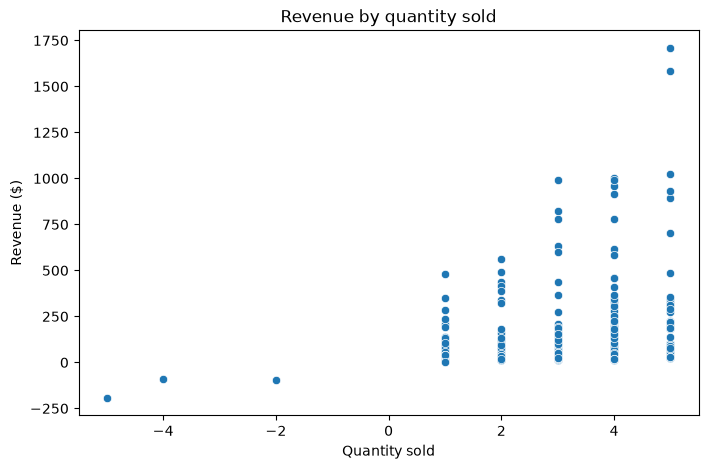

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=sales, x="qty", y="revenue")

plt.title("Revenue by quantity sold")
plt.xlabel("Quantity sold")
plt.ylabel("Revenue ($)")

plt.show()

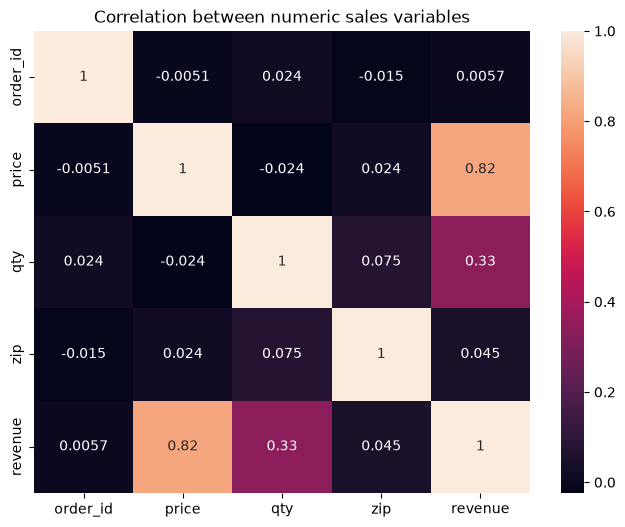

In [11]:
corr = sales.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True)

plt.title("Correlation between numeric sales variables")

plt.show()

The strongest correlation is between price and revenue (0.82).

The null hypothesis is that sunflower-fed and horsebean-fed chicks have the same mean weight.

In [12]:
sunflower = df[df["feed"] == "sunflower"]["weight"]
horsebean = df[df["feed"] == "horsebean"]["weight"]

t_stat, p_value = ttest_ind(sunflower, horsebean)

print("Sunflower mean:", sunflower.mean())
print("Horsebean mean:", horsebean.mean())
print("Difference:", sunflower.mean() - horsebean.mean())
print("t-statistic:", t_stat)
print("p-value:", p_value)

Sunflower mean: 328.9166666666667
Horsebean mean: 160.2
Difference: 168.7166666666667
t-statistic: 8.848346742516636
p-value: 2.374350767683718e-08


The sunflower-fed chicks were about 168.7 g heavier on average than the horsebean-fed chicks. Since the p-value was below 0.001, I reject the null hypothesis, but the results are based on a limited sample from one dataset.

To keep the bar chart accurate and easy to understand, the y-axis begins at zero and the weight values are clearly labeled in grams.